Step one

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Warnungen unterdrücken (z.B. von älteren Pandas-Versionen)
warnings.filterwarnings("ignore")

# Seaborn-Theme einmalig setzen – gilt für alle folgenden Plots
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# Pandas: alle Spalten anzeigen, Dezimalstellen begrenzen
pd.set_option("display.float_format", lambda x: "%.2f" % x)
pd.set_option("display.max_columns", None)

print("Bibliotheken geladen.")

Bibliotheken geladen.


In [2]:
# ── DATEN LADEN ───────────────────────────────────────────────
# parse_dates parse string values to a datetime format. important for time series analysis, 
# as it allows the date column to be recognized as a date rather than text.
# (Bonnies Timing-question)
df = pd.read_csv(
    "king_county_houses.csv",
    parse_dates=["date"]
)

print(f"Datensatz geladen: {df.shape[0]:,} Zeilen · {df.shape[1]} Spalten")


Datensatz geladen: 21,597 Zeilen · 22 Spalten


In [3]:
df.head(15)

,sale_id,date,price,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,1,2014-10-13,221900.00,7129300520,3.00,1.00,1180.00,5650.00,1.00,NaN,0.00,3,7,1180.00,0.00,1955,0.00,98178,47.51,-122.26,1340.00,5650.00
1,2,2014-12-09,538000.00,6414100192,3.00,2.25,2570.00,7242.00,2.00,0.00,0.00,3,7,2170.00,400.00,1951,19910.00,98125,47.72,-122.32,1690.00,7639.00
2,3,2015-02-25,180000.00,5631500400,2.00,1.00,770.00,10000.00,1.00,0.00,0.00,3,6,770.00,0.00,1933,NaN,98028,47.74,-122.23,2720.00,8062.00
3,4,2014-12-09,604000.00,2487200875,4.00,3.00,1960.00,5000.00,1.00,0.00,0.00,5,7,1050.00,910.00,1965,0.00,98136,47.52,-122.39,1360.00,5000.00
4,5,2015-02-18,510000.00,1954400510,3.00,2.00,1680.00,8080.00,1.00,0.00,0.00,3,8,1680.00,0.00,1987,0.00,98074,47.62,-122.05,1800.00,7503.00
5,6,2014-05-12,1230000.00,7237550310,4.00,4.50,5420.00,101930.00,1.00,0.00,0.00,3,11,3890.00,1530.00,2001,0.00,98053,47.66,-122.00,4760.00,101930.00
6,7,2014-06-27,257500.00,1321400060,3.00,2.25,1715.00,6819.00,2.00,0.00,0.00,3,7,1715.00,NaN,1995,0.00,98003,47.31,-122.33,2238.00,6819.00
7,8,2015-01-15,291850.00,2008000270,3.00,1.50,1060.00,9711.00,1.00,0.00,NaN,3,7,1060.00,0.00,1963,0.00,98198,47.41,-122.31,1650.00,9711.00
8,9,2015-04-15,229500.00,2414600126,3.00,1.00,1780.00,7470.00,1.00,0.00,0.00,3,7,1050.00,730.00,1960,0.00,98146,47.51,-122.34,1780.00,8113.00
9,10,2015-03-12,323000.00,3793500160,3.00,2.50,1890.00,6560.00,2.00,0.00,0.00,3,7,1890.00,0.00,2003,0.00,98038,47.37,-122.03,2390.00,7570.00


In [4]:
# overview
df.shape

(21597, 22)

In [5]:
# controll datatype of date column
df. info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sale_id        21597 non-null  int64         
 1   date           21597 non-null  datetime64[us]
 2   price          21597 non-null  float64       
 3   house_id       21597 non-null  int64         
 4   bedrooms       21597 non-null  float64       
 5   bathrooms      21597 non-null  float64       
 6   sqft_living    21597 non-null  float64       
 7   sqft_lot       21597 non-null  float64       
 8   floors         21597 non-null  float64       
 9   waterfront     19206 non-null  float64       
 10  view           21534 non-null  float64       
 11  condition      21597 non-null  int64         
 12  grade          21597 non-null  int64         
 13  sqft_above     21597 non-null  float64       
 14  sqft_basement  21145 non-null  float64       
 15  yr_built       21597 non-null 

In [6]:
df.describe()

,sale_id,date,price,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21597.00,21597,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,19206.00,21534.00,21597.00,21597.00,21597.00,21145.00,21597.00,17749.00,21597.00,21597.00,21597.00,21597.00,21597.00
mean,10799.00,2014-10-29 04:20:38.171968,540296.57,4580474287.77,3.37,2.12,2080.32,15099.41,1.49,0.01,0.23,3.41,7.66,1788.60,291.86,1971.00,836.65,98077.95,47.56,-122.21,1986.62,12758.28
min,1.00,2014-05-02 00:00:00,78000.00,1000102.00,1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,3.00,370.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00
25%,5400.00,2014-07-22 00:00:00,322000.00,2123049175.00,3.00,1.75,1430.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00
50%,10799.00,2014-10-16 00:00:00,450000.00,3904930410.00,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00
75%,16198.00,2015-02-17 00:00:00,645000.00,7308900490.00,4.00,2.50,2550.00,10685.00,2.00,0.00,0.00,4.00,8.00,2210.00,560.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00
max,21597.00,2015-05-27 00:00:00,7700000.00,9900000190.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,20150.00,98199.00,47.78,-121.31,6210.00,871200.00
std,6234.66,NaN,367368.14,2876735715.75,0.93,0.77,918.11,41412.64,0.54,0.09,0.77,0.65,1.17,827.76,442.49,29.38,4000.11,53.51,0.14,0.14,685.23,27274.44


In [7]:
# how much NaN values do we have in each column?
df.isna().sum() 
# info() shows how much non-null values we have, but isna().sum() shows how much NaN values we have in each column.

sale_id             0
date                0
price               0
house_id            0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64

important question: why are these values missing?

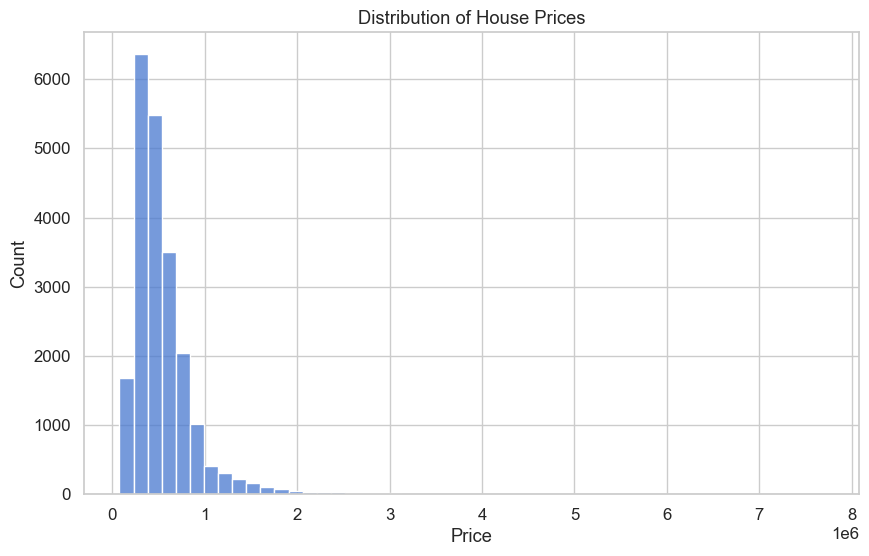

In [8]:
# Histogramm , fist data view
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="price", bins=50)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [9]:
# Boxplot, price from grade

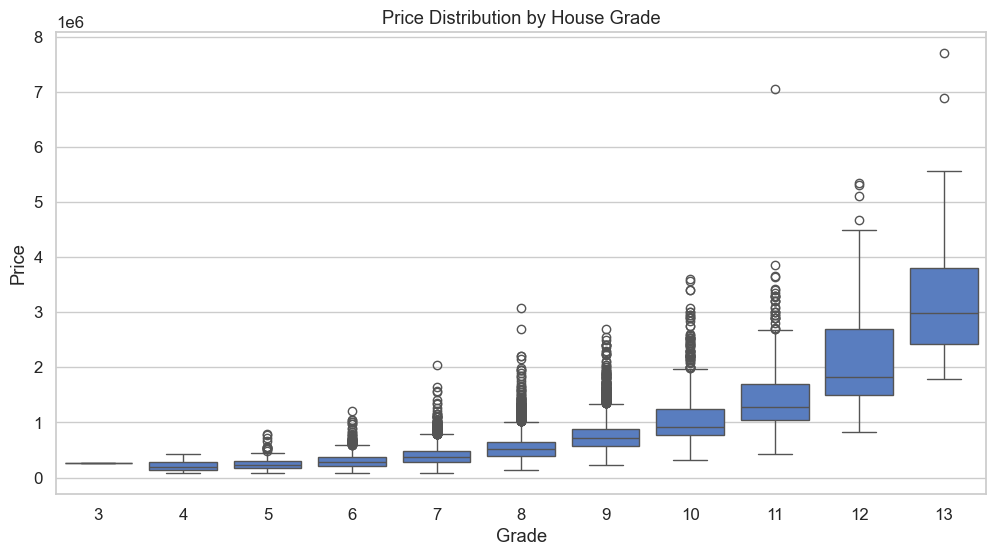

In [10]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x="grade", y="price")

plt.title("Price Distribution by House Grade")
plt.xlabel("Grade")
plt.ylabel("Price")

plt.show()

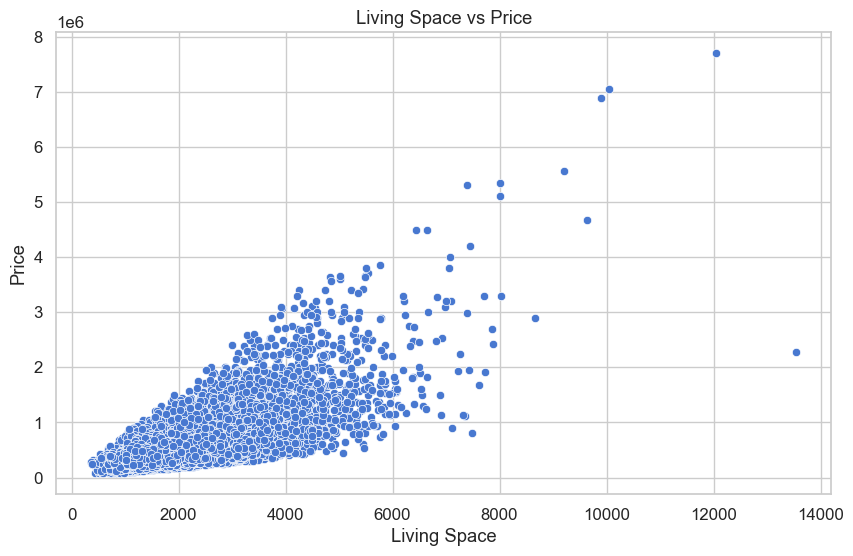

In [11]:
# Scatterplot. price from sqft_living
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="sqft_living",
    y="price"
)

plt.title("Living Space vs Price")
plt.xlabel("Living Space")
plt.ylabel("Price")

plt.show()

In [12]:
# segment price
zipcode_prices = (
    df.groupby("zipcode")["price"]
    .median()
    .sort_values()
)

zipcode_prices.head()

zipcode
98002   235000.00
98168   235000.00
98032   249000.00
98001   260000.00
98188   264000.00
Name: price, dtype: float64

In [13]:
# how many houses have waterfront view?
df["waterfront"].value_counts(dropna=False)

waterfront
0.00    19060
NaN      2391
1.00      146
Name: count, dtype: int64

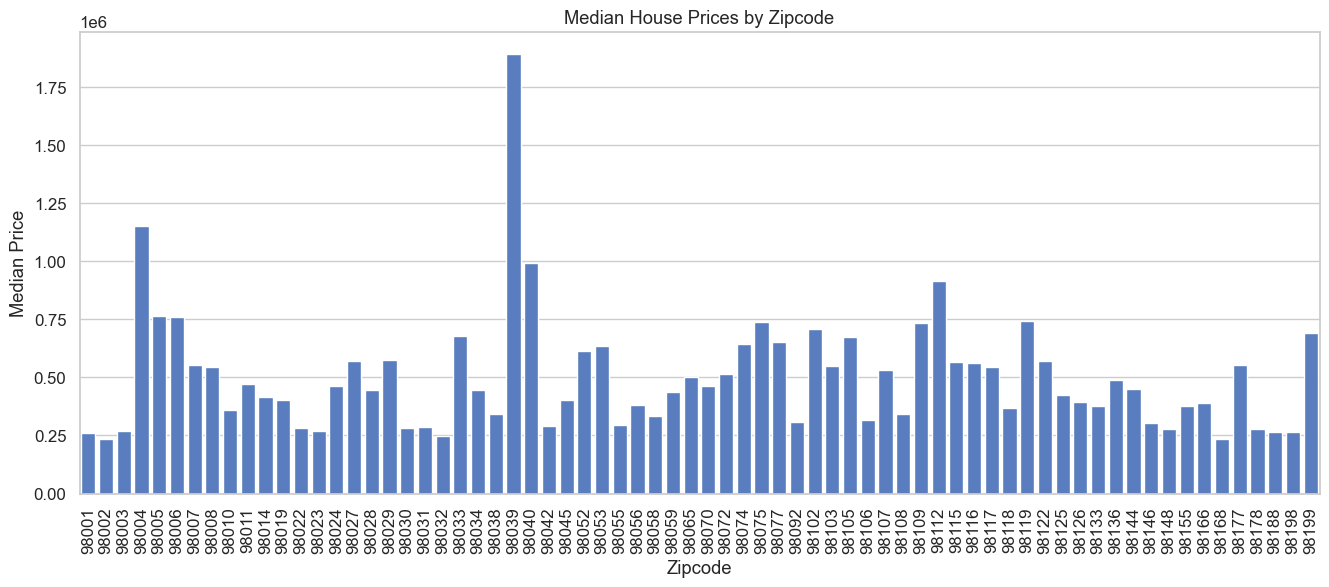

In [14]:
# median price from zipcode
zipcode_prices = (
    df.groupby("zipcode")["price"]
    .median()
    .sort_values()
)

plt.figure(figsize=(16, 6))

sns.barplot(
    x=zipcode_prices.index,
    y=zipcode_prices.values
)

plt.xticks(rotation=90)

plt.title("Median House Prices by Zipcode")
plt.xlabel("Zipcode")
plt.ylabel("Median Price")

plt.show()

In [15]:
# table for month for time series analysis
df["month"] = df["date"].dt.month

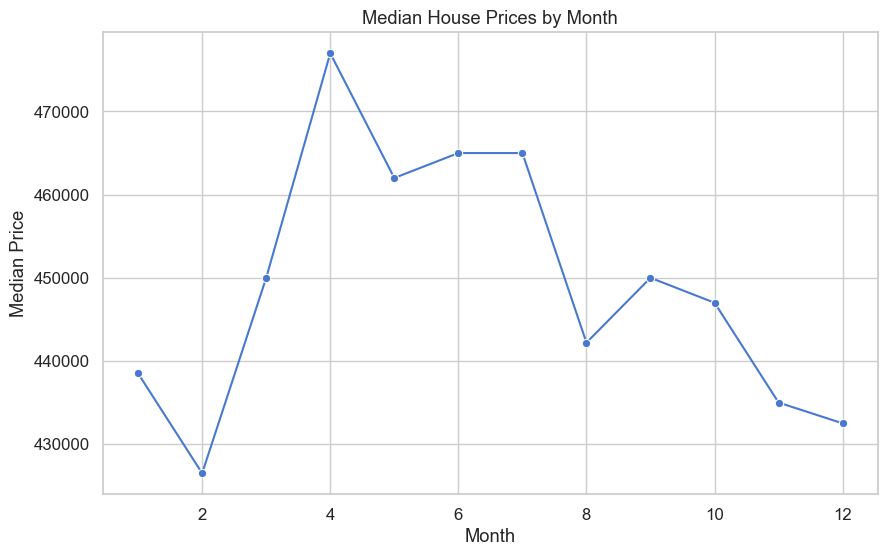

In [16]:
# lineplot for price and timerange
monthly_prices = (
    df.groupby("month")["price"]
    .median()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=monthly_prices.index,
    y=monthly_prices.values,
    marker="o"
)

plt.title("Median House Prices by Month")
plt.xlabel("Month")
plt.ylabel("Median Price")

plt.show()

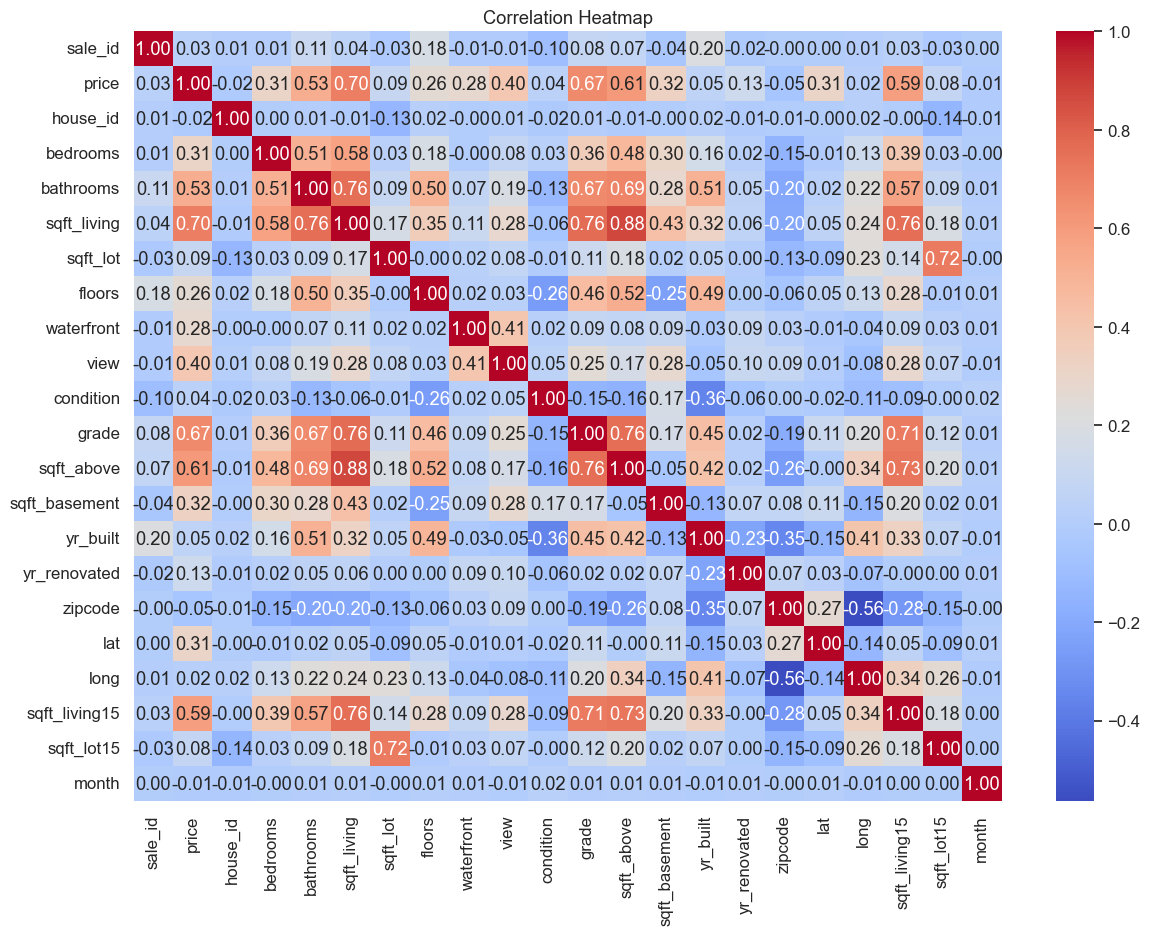

In [17]:
# heatmap for correlation
plt.figure(figsize=(14, 10))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
# check problem-columns
df["waterfront"].value_counts(dropna=False)

waterfront
0.00    19060
NaN      2391
1.00      146
Name: count, dtype: int64

In [19]:
# check wrong date
df["yr_renovated"].sort_values(ascending=False).head(20)

14845   20150.00
11587   20150.00
18560   20150.00
3153    20150.00
11621   20150.00
16669   20150.00
4236    20150.00
7090    20150.00
19429   20150.00
5678    20150.00
15673   20150.00
2293    20150.00
8683    20150.00
7410    20150.00
5185    20140.00
2503    20140.00
1893    20140.00
15032   20140.00
11683   20140.00
3186    20140.00
Name: yr_renovated, dtype: float64

In [20]:
df_renovated= df["renovated"] =df["yr_renovated"] > 0
df_renovated.head()

0    False
1     True
2    False
3    False
4    False
Name: yr_renovated, dtype: bool

In [21]:
df["yr_renovated"] \
    .sort_values(ascending=False) \
    .head(20)

14845   20150.00
11587   20150.00
18560   20150.00
3153    20150.00
11621   20150.00
16669   20150.00
4236    20150.00
7090    20150.00
19429   20150.00
5678    20150.00
15673   20150.00
2293    20150.00
8683    20150.00
7410    20150.00
5185    20140.00
2503    20140.00
1893    20140.00
15032   20140.00
11683   20140.00
3186    20140.00
Name: yr_renovated, dtype: float64

In [22]:
import numpy as np

df.loc[
    df["yr_renovated"] > 2025,
    "yr_renovated"
] = np.nan

In [23]:
df["renovated"].value_counts()

renovated
False    20853
True       744
Name: count, dtype: int64

In [24]:
filtered_df = df[
    df["price"] < 2000000
]

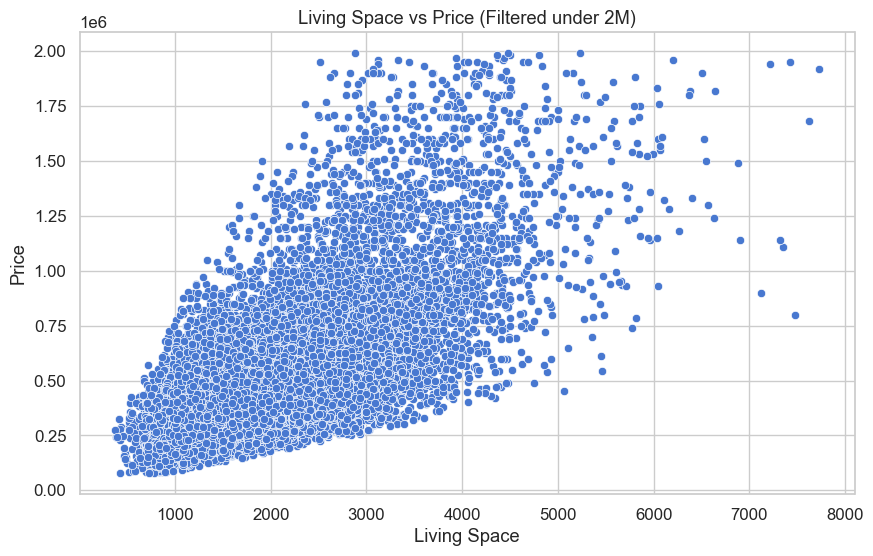

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=filtered_df,
    x="sqft_living",
    y="price"
)

plt.title(
    "Living Space vs Price "
    "(Filtered under 2M)"
)

plt.xlabel("Living Space")
plt.ylabel("Price")

plt.show()

In [26]:
import pandas as pd

# Small feature overview table
feature_table = pd.DataFrame({
    "Feature": [
        "price",
        "sqft_living",
        "grade",
        "zipcode",
        "view",
        "waterfront",
        "condition",
        "month"
    ],
    
    "Meaning": [
        "selling price",
        "living space",
        "overall quality",
        "location",
        "quality of view",
        "water access",
        "house condition",
        "month of sale"
    ]
})

print(feature_table)

       Feature          Meaning
0        price    selling price
1  sqft_living     living space
2        grade  overall quality
3      zipcode         location
4         view  quality of view
5   waterfront     water access
6    condition  house condition
7        month    month of sale


In [27]:
# boxplot better

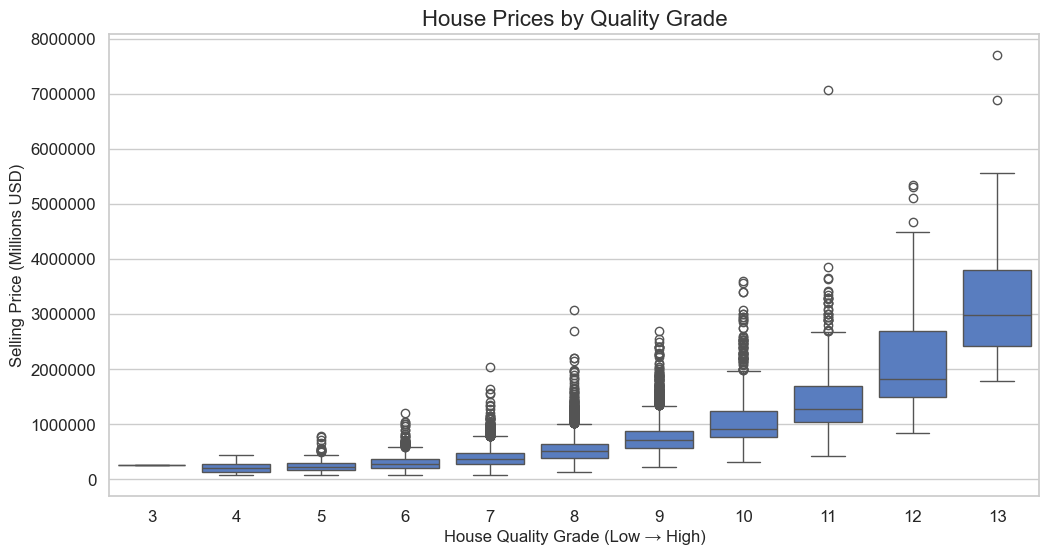

In [28]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="grade",
    y="price"
)

plt.title(
    "House Prices by Quality Grade",
    fontsize=16
)

plt.xlabel(
    "House Quality Grade (Low → High)",
    fontsize=12
)

plt.ylabel(
    "Selling Price (Millions USD)",
    fontsize=12
)

# Better y-axis readability
plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.show()

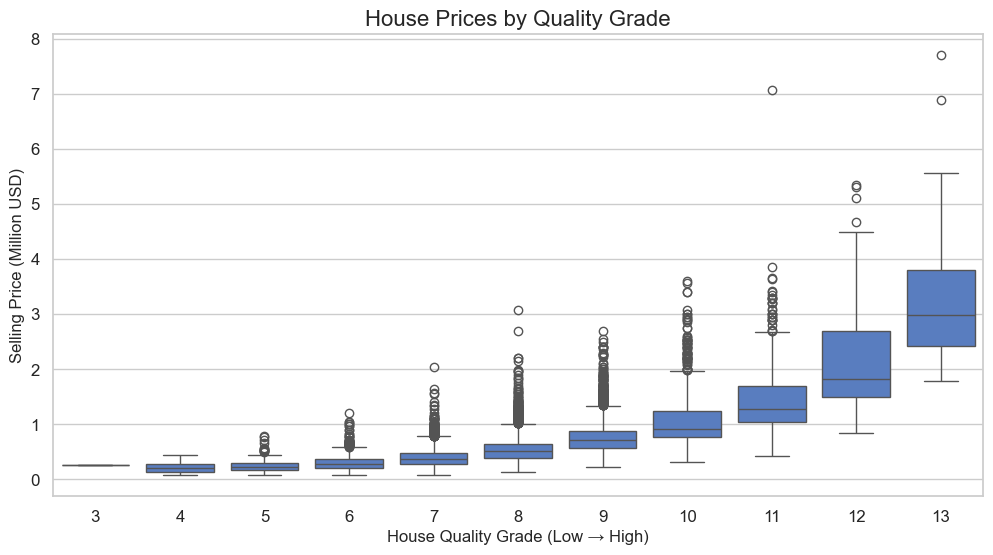

In [29]:
# box-plot 3
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="grade",
    y=df["price"] / 1_000_000
)

plt.title(
    "House Prices by Quality Grade",
    fontsize=16
)

plt.xlabel(
    "House Quality Grade (Low → High)",
    fontsize=12
)

plt.ylabel(
    "Selling Price (Million USD)",
    fontsize=12
)

plt.show()